# 03 - Text features, fusion models and saving the final model

Now both modalities are ready:

* **text**: TF-IDF (1-2 word n-grams) on the cleaned tweet. Light and fast; no transformer download.
* **image**: the 576-d MobileNet vector from notebook 02.

I compare these ways of using them:

1. text only
2. image only
3. **early fusion**: glue the two feature vectors together and train one classifier (logistic regression and a small MLP)
4. **late fusion**: train one model per modality and average their probabilities, with a weight picked on the validation set

The winner (by validation macro-F1) is saved for the web app.

In [1]:
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix, classification_report, ConfusionMatrixDisplay

SEED = 42
DATA_DIR = Path("../data")
MODEL_DIR = Path("../models")
STATIC_DIR = Path("../static")

In [2]:
df = pd.read_csv(DATA_DIR / "dataset.csv")
npz = np.load(DATA_DIR / "image_features.npz")

# keep only tweets whose image features exist, in the same order as the feature matrix
row_of = pd.Series(np.arange(len(npz["ids"])), index=npz["ids"])
df = df[df["id"].isin(row_of.index)].reset_index(drop=True)
X_img = npz["feats"][row_of[df["id"]].values]
texts = df["text"].fillna("").values
y = df["label"].values

train = (df["split"] == "train").values
val = (df["split"] == "val").values
test = (df["split"] == "test").values
print("train / val / test:", train.sum(), val.sum(), test.sum())
print("image matrix:", X_img.shape)

train / val / test: 389 49 49
image matrix: (487, 576)


## Building the feature matrices
Everything is fitted on the training rows only, then applied to val and test.

In [3]:
tfidf = TfidfVectorizer(ngram_range=(1, 2), min_df=2, max_features=20000, sublinear_tf=True)
T_train = tfidf.fit_transform(texts[train])
T_val = tfidf.transform(texts[val])
T_test = tfidf.transform(texts[test])
print("tfidf vocabulary:", len(tfidf.vocabulary_))

# early fusion needs dense vectors of a similar size, so the sparse tf-idf goes through a truncated SVD (LSA)
n_comp = int(min(200, T_train.shape[1] - 1, T_train.shape[0] - 1))
svd = TruncatedSVD(n_components=n_comp, random_state=SEED)
S_train = svd.fit_transform(T_train)
S_val = svd.transform(T_val)
S_test = svd.transform(T_test)

img_scaler = StandardScaler().fit(X_img[train])
I_train, I_val, I_test = (img_scaler.transform(X_img[m]) for m in (train, val, test))

fuse_train = np.hstack([S_train, X_img[train]])
fuse_scaler = StandardScaler().fit(fuse_train)
F_train = fuse_scaler.transform(fuse_train)
F_val = fuse_scaler.transform(np.hstack([S_val, X_img[val]]))
F_test = fuse_scaler.transform(np.hstack([S_test, X_img[test]]))
print("fused vector size:", F_train.shape[1], f"({n_comp} text + {X_img.shape[1]} image)")

tfidf vocabulary: 657
fused vector size: 776 (200 text + 576 image)


## Models

Classes are unbalanced, so logistic regression gets `class_weight="balanced"`. The regularisation strength C
is picked from a small grid using the validation set.

In [4]:
y_train, y_val, y_test = y[train], y[val], y[test]


def macro_f1(y_true, y_pred):
    return f1_score(y_true, y_pred, average="macro")


def fit_lr(X_tr, X_va, grid=(0.01, 0.1, 1, 10)):
    best, best_score = None, -1
    for C in grid:
        clf = LogisticRegression(C=C, max_iter=3000, class_weight="balanced")
        clf.fit(X_tr, y_train)
        score = macro_f1(y_val, clf.predict(X_va))
        if score > best_score:
            best, best_score = clf, score
    print(f"  best C={best.C}  val macro-F1={best_score:.3f}")
    return best


print("text only");  text_clf = fit_lr(T_train, T_val)
print("image only"); image_clf = fit_lr(I_train, I_val, grid=(0.0005, 0.005, 0.05, 0.5))
print("early fusion (logistic regression)"); early_lr = fit_lr(F_train, F_val, grid=(0.0005, 0.005, 0.05, 0.5))

text only
  best C=0.01  val macro-F1=0.358
image only
  best C=0.005  val macro-F1=0.519
early fusion (logistic regression)
  best C=0.0005  val macro-F1=0.461


In [5]:
# MLPClassifier + early_stopping breaks on string labels in recent scikit-learn, so it gets integer codes
# (0, 1, 2 = alphabetical order of the class names, the same column order predict_proba uses everywhere else)
class_names = np.array(sorted(set(y)))
to_code = {c: i for i, c in enumerate(class_names)}
y_train_code = np.array([to_code[c] for c in y_train])

early_mlp = MLPClassifier(hidden_layer_sizes=(256, 64), alpha=1e-2, early_stopping=True,
                          n_iter_no_change=8, max_iter=300, random_state=SEED)
early_mlp.fit(F_train, y_train_code)
print("early fusion (MLP)  val macro-F1 =", round(macro_f1(y_val, class_names[early_mlp.predict(F_val)]), 3))

early fusion (MLP)  val macro-F1 = 0.386


In [6]:
# late fusion: p = w * p_text + (1 - w) * p_image, w chosen on the validation set
classes = list(text_clf.classes_)
assert classes == list(image_clf.classes_) == list(early_lr.classes_) == list(class_names)

pt_val, pi_val = text_clf.predict_proba(T_val), image_clf.predict_proba(I_val)
pt_test, pi_test = text_clf.predict_proba(T_test), image_clf.predict_proba(I_test)

best_w, best_score = 0.5, -1
for w in np.linspace(0, 1, 11):
    pred = np.array(classes)[(w * pt_val + (1 - w) * pi_val).argmax(1)]
    score = macro_f1(y_val, pred)
    if score > best_score:
        best_w, best_score = float(w), score
print(f"late fusion weight on text = {best_w:.1f}  val macro-F1 = {best_score:.3f}")

late fusion weight on text = 0.6  val macro-F1 = 0.542


## Comparison

In [7]:
def predict_all(split):
    if split == "val":
        T, I, F, pt, pi = T_val, I_val, F_val, pt_val, pi_val
    else:
        T, I, F, pt, pi = T_test, I_test, F_test, pt_test, pi_test
    cls = np.array(classes)
    return {
        "text only": cls[pt.argmax(1)],
        "image only": cls[pi.argmax(1)],
        "early fusion (LR)": early_lr.predict(F),
        "early fusion (MLP)": class_names[early_mlp.predict(F)],
        "late fusion": cls[(best_w * pt + (1 - best_w) * pi).argmax(1)],
    }


val_preds, test_preds = predict_all("val"), predict_all("test")

table = pd.DataFrame([{
    "model": name,
    "val_macro_f1": macro_f1(y_val, val_preds[name]),
    "test_accuracy": accuracy_score(y_test, test_preds[name]),
    "test_macro_f1": macro_f1(y_test, test_preds[name]),
} for name in val_preds]).round(3)
table

,model,val_macro_f1,test_accuracy,test_macro_f1
0,text only,0.358,0.633,0.512
1,image only,0.519,0.510,0.442
2,early fusion (LR),0.461,0.531,0.464
3,early fusion (MLP),0.386,0.612,0.511
4,late fusion,0.542,0.510,0.442


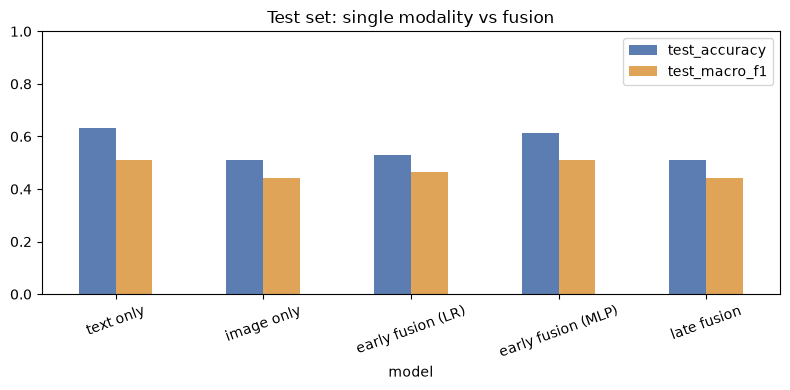

In [8]:
ax = table.set_index("model")[["test_accuracy", "test_macro_f1"]].plot.bar(figsize=(8, 4), rot=20, color=["#5b7db1", "#e0a458"])
ax.set_title("Test set: single modality vs fusion")
ax.set_ylim(0, 1)
plt.tight_layout()
plt.savefig(STATIC_DIR / "model_comparison.png", dpi=130)
plt.show()

## Pick the model to deploy

Only the fusion models are candidates (the app also shows the single-modality predictions next to the fused one
so you can see what fusion adds). Decision uses **validation** macro-F1; the test set stays untouched until now.

deploying: late fusion
              precision    recall  f1-score   support

    negative      0.308     0.267     0.286        15
     neutral      0.273     0.600     0.375         5
    positive      0.720     0.621     0.667        29

    accuracy                          0.510        49
   macro avg      0.433     0.496     0.442        49
weighted avg      0.548     0.510     0.520        49



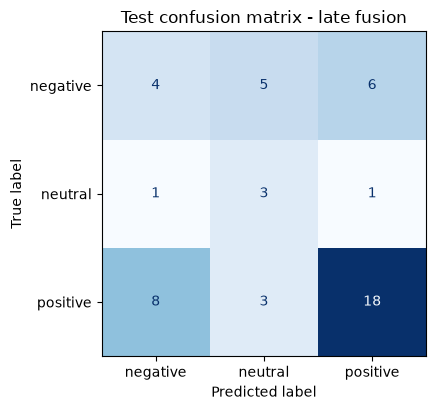

In [9]:
candidates = ["early fusion (LR)", "early fusion (MLP)", "late fusion"]
winner = max(candidates, key=lambda n: table.set_index("model").loc[n, "val_macro_f1"])
print("deploying:", winner)

final_pred = test_preds[winner]
print(classification_report(y_test, final_pred, digits=3, zero_division=0))

cm = confusion_matrix(y_test, final_pred, labels=classes)
disp = ConfusionMatrixDisplay(cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(4.8, 4.2))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Test confusion matrix - {winner}")
plt.tight_layout()
plt.savefig(STATIC_DIR / "confusion_matrix.png", dpi=130)
plt.show()

Where does the image or the text alone go wrong while the fused model gets it right? (and the other way round)

In [10]:
fused_ok = final_pred == y_test
text_ok = test_preds["text only"] == y_test
image_ok = test_preds["image only"] == y_test

print("fusion right, text wrong :", int((fused_ok & ~text_ok).sum()))
print("fusion right, image wrong:", int((fused_ok & ~image_ok).sum()))
print("fusion wrong, text right :", int((~fused_ok & text_ok).sum()))
print("fusion wrong, image right:", int((~fused_ok & image_ok).sum()))
print("both single models wrong but fusion right:", int((fused_ok & ~text_ok & ~image_ok).sum()))

fusion right, text wrong : 9
fusion right, image wrong: 0
fusion wrong, text right : 15
fusion wrong, image right: 0
both single models wrong but fusion right: 0


## Save for the web app

In [11]:
early_best = early_mlp if winner == "early fusion (MLP)" else early_lr

bundle = {
    "classes": classes,
    "tfidf": tfidf,
    "svd": svd,
    "img_scaler": img_scaler,
    "fuse_scaler": fuse_scaler,
    "text_clf": text_clf,
    "image_clf": image_clf,
    "early_clf": early_best,
    "late_w": best_w,
    "deploy": "late" if winner == "late fusion" else "early",
    "backbone": "mobilenet_v3_small",
}
joblib.dump(bundle, MODEL_DIR / "fusion_bundle.joblib", compress=3)

metrics = {
    "deployed": winner,
    "sizes": {"train": int(train.sum()), "val": int(val.sum()), "test": int(test.sum())},
    "models": table.to_dict(orient="records"),
}
(MODEL_DIR / "metrics.json").write_text(json.dumps(metrics, indent=2))

print("bundle:", round((MODEL_DIR / "fusion_bundle.joblib").stat().st_size / 1e6, 1), "MB")

bundle: 1.0 MB


Done. Start the app from the repo root with `python app.py` and open http://127.0.0.1:5000.

If you want your disk back: `data/data.zip` (211 MB) is no longer needed once notebooks 01-03 have run.